# Exploratory Data Analysis (EDA) - Market Data Layer
This notebook queries our local Parquet storage layer using **DuckDB** and performs exploratory analysis on our ingested historical market data (`AAPL` and `RELIANCE.NS`).

In [1]:
import os
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plotting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Data via DuckDB
We read from our partitioned analytical Parquet files directly using DuckDB.

In [2]:
db_dir = "./data_storage/parquet/ohlcv"
con = duckdb.connect(database=":memory:")

# Scan all parquet files recursively in data_storage
df = con.execute(f"""
    SELECT timestamp, instrument_id, open, high, low, close, volume, currency, source
    FROM read_parquet('{db_dir}/**/*.parquet')
    ORDER BY timestamp ASC
""").df()

print(f"Loaded {len(df)} records.")
df.head()

Loaded 19 records.


,timestamp,instrument_id,open,high,low,close,volume,currency,source
0,2026-08-03T00:00:00-04:00,a1000000-0000-0000-0000-000000000001,309.313235,311.531323,302.299295,303.158569,75052000,USD,yfinance
1,2026-08-04T00:00:00-04:00,a1000000-0000-0000-0000-000000000001,302.469140,310.152516,301.060351,309.113403,68001000,USD,yfinance
2,2026-08-05T00:00:00-04:00,a1000000-0000-0000-0000-000000000001,309.093424,311.441405,305.406631,310.732025,49438800,USD,yfinance
3,2026-08-06T00:00:00-04:00,a1000000-0000-0000-0000-000000000001,314.069138,316.017470,308.963556,312.140808,46139900,USD,yfinance
4,2026-08-07T00:00:00-04:00,a1000000-0000-0000-0000-000000000001,311.181643,314.538733,310.472233,313.059998,34437200,USD,yfinance


## 2. General Data Quality & Summary Statistics

In [3]:
print("--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Descriptive Summary ---")
print(df.groupby('instrument_id')[['close', 'volume']].describe())

--- Missing Values Check ---
timestamp        0
instrument_id    0
open             0
high             0
low              0
close            0
volume           0
currency         0
source           0
dtype: int64

--- Descriptive Summary ---
                                     close                                \
                                     count        mean       std     min   
instrument_id                                                              
a1000000-0000-0000-0000-000000000001  19.0  309.272883  3.953014  302.25   

                                                                          \
                                             25%         50%         75%   
instrument_id                                                              
a1000000-0000-0000-0000-000000000001  305.759995  309.899994  311.720398   

                                                 volume                \
                                             max  count          mean   
in

## 3. Stock Price Trend Visualization

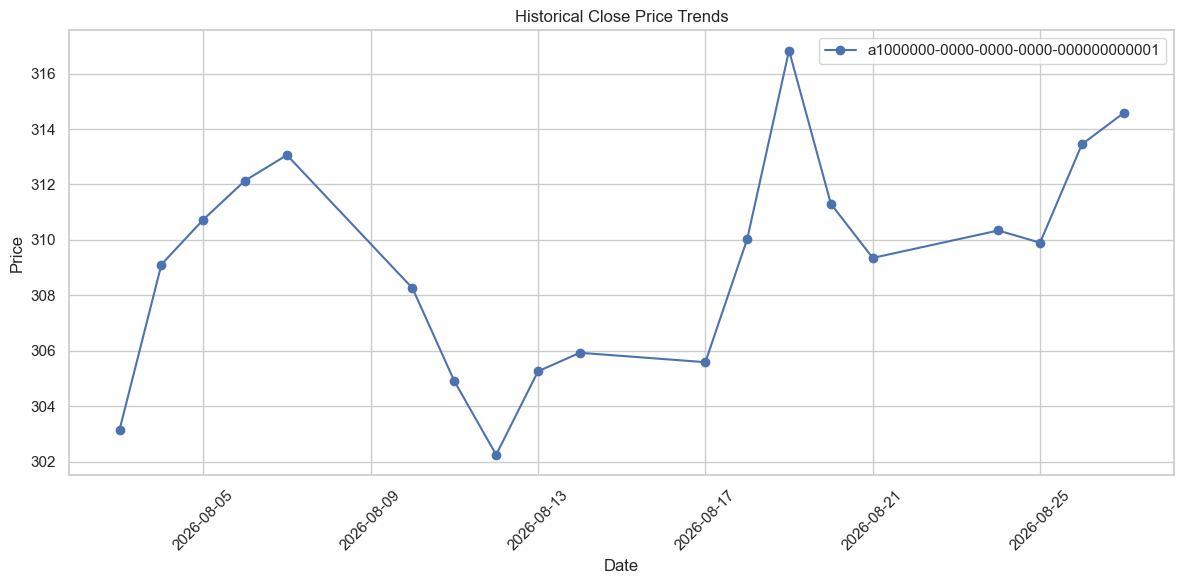

In [4]:
for inst_id, group in df.groupby('instrument_id'):
    plt.plot(pd.to_datetime(group['timestamp']), group['close'], label=inst_id, marker='o')

plt.title("Historical Close Price Trends")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Return Distributions & Volatility Analysis
We calculate daily percentage returns to analyze asset volatility.

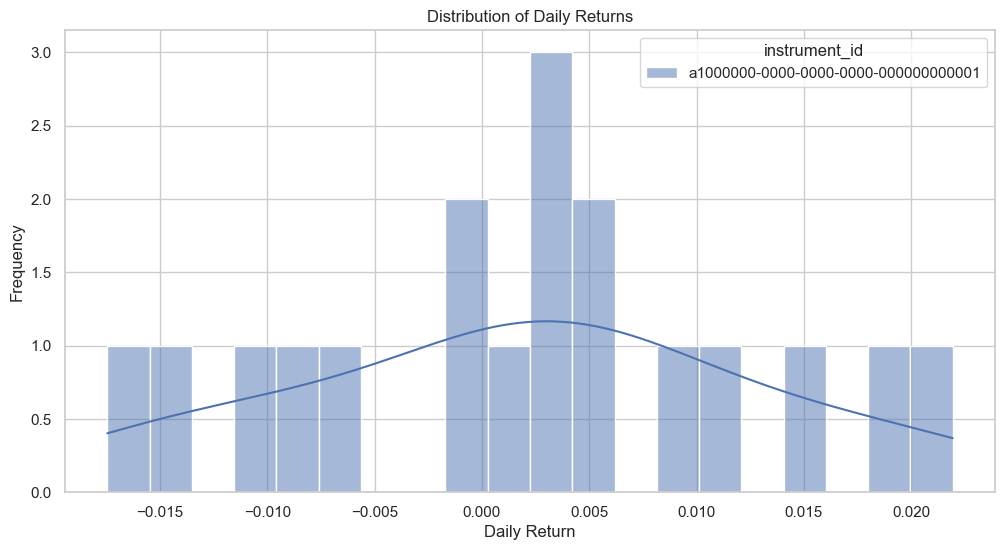

In [5]:
df['returns'] = df.groupby('instrument_id')['close'].pct_change()

# Plot returns distribution
sns.histplot(data=df, x='returns', hue='instrument_id', kde=True, bins=20, multiple="dodge")
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

## 5. Volatility (5-Day Rolling Std Dev)

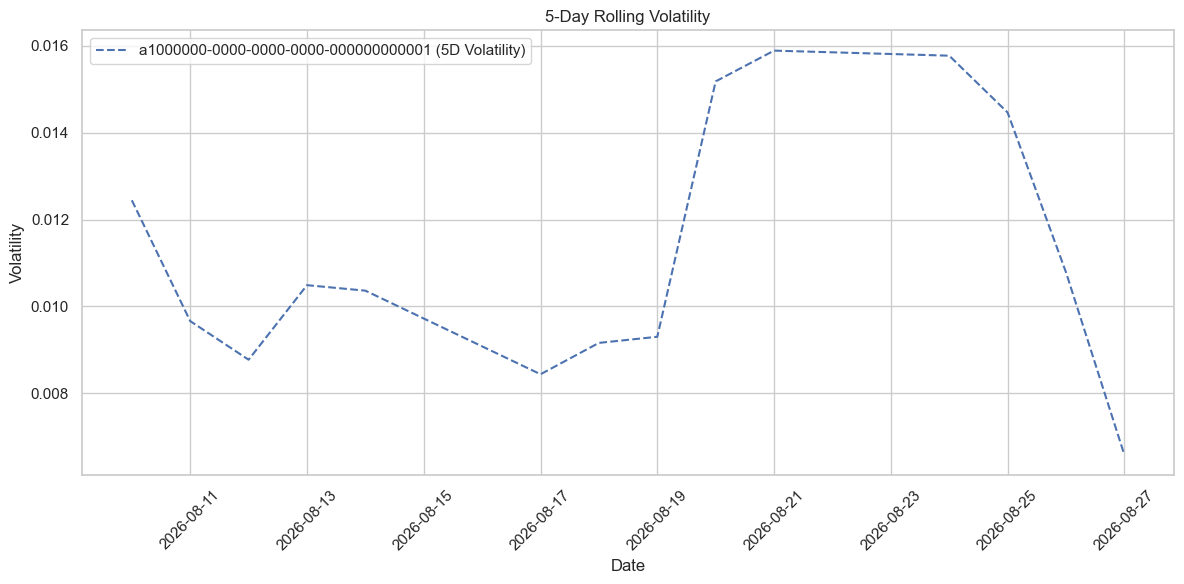

In [6]:
df['volatility_5d'] = df.groupby('instrument_id')['returns'].transform(lambda x: x.rolling(5).std())

for inst_id, group in df.groupby('instrument_id'):
    plt.plot(pd.to_datetime(group['timestamp']), group['volatility_5d'], label=f"{inst_id} (5D Volatility)", linestyle='--')

plt.title("5-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Correlation Analysis
Let's see if our assets (AAPL and RELIANCE) have any daily price correlation.

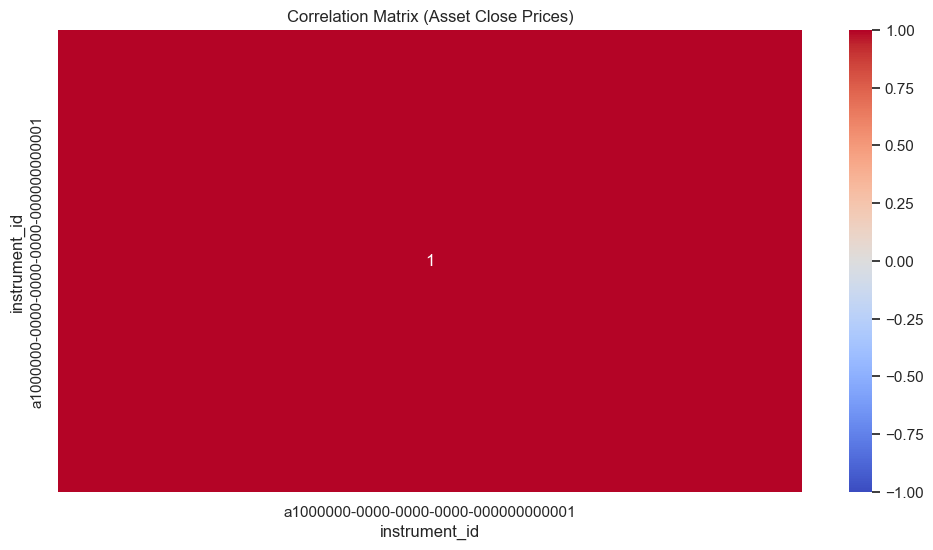

In [7]:
pivot_df = df.pivot(index='timestamp', columns='instrument_id', values='close').dropna()
corr = pivot_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Asset Close Prices)")
plt.show()